# Planet Type Prediction

Exoplanets are classified into 4 different classes: 

1. Gas giants are planets the size of Saturn or Jupiter, the largest planet in our solar system, or much, much larger.
    More variety is hidden within these broad categories. Hot Jupiters, for instance, were among the first planet types found – gas giants orbiting so closely to their stars that their temperatures soar into the thousands of degrees (Fahrenheit or Celsius).

2. Neptunian planets are similar in size to Neptune or Uranus in our solar system. They likely have a mixture of interior compositions, but all will have hydrogen and helium-dominated outer atmospheres and rocky cores. We’re also discovering mini-Neptunes, planets smaller than Neptune and bigger than Earth. No planets of this size or type exist in our solar system.

3. Super-Earths are typically terrestrial planets that may or may not have atmospheres. They are more massive than Earth, but lighter than Neptune.

4. Terrestrial planets are Earth sized and smaller, composed of rock, silicate, water or carbon. Further investigation will determine whether some of them possess atmospheres, oceans or other signs of habitability.

from: https://science.nasa.gov/exoplanets/

Because of that wiggle room, this dataset has classified exoplanets into 7 different classes:

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
X_cleaned = pd.read_csv('./data/X_Planet_Type.csv')
y_cleaned = pd.read_csv('./data/Y_Planet_Type.csv')
X_cleaned

,Unnamed: 0,planet_radius_earth,planet_mass_earth,orbital_period_days,equilibrium_temp_k,orbital_period_cat,dec,disc_facility,orbital_eccentricity,discovery_method,star_radius_sun
0,0,-0.747156,-0.330671,-0.152893,1.110810,0.077980,0.786910,-0.449568,-0.494351,0.371310,-0.332594
1,1,-0.433212,-0.321763,-0.149129,-0.124596,0.077980,0.546120,-0.449568,-0.494351,0.371310,-0.213816
2,2,-0.924249,-0.334428,-0.150120,0.425941,0.077980,0.564819,-0.449568,-0.494351,0.371310,0.035235
3,3,-0.466921,-0.322842,-0.151753,1.630517,0.077980,0.671591,-0.449568,-0.494351,0.371310,0.479696
4,4,-0.196298,-0.312530,-0.123824,-1.091339,-0.738437,0.883779,-0.449568,-0.494351,0.371310,-0.278186
...,...,...,...,...,...,...,...,...,...,...,...
5837,5837,0.190854,-0.327758,-0.146908,-0.184054,-0.738437,0.030983,-0.859811,-0.432286,0.371310,0.104203
5838,5838,1.605652,0.068994,1.081415,-1.274117,1.710815,-1.260327,-0.586316,-0.110975,-3.924126,0.029993
5839,5839,0.225883,-0.291308,-0.109366,-0.670729,-0.738437,-2.194293,1.875143,-0.494351,0.371310,0.579316
5840,5840,-0.810987,-0.331019,-0.152288,-0.261129,0.077980,0.804313,1.875143,-0.387342,0.371310,-0.494286


In [6]:
y_cleaned = y_cleaned.drop(columns=['Unnamed: 0'])

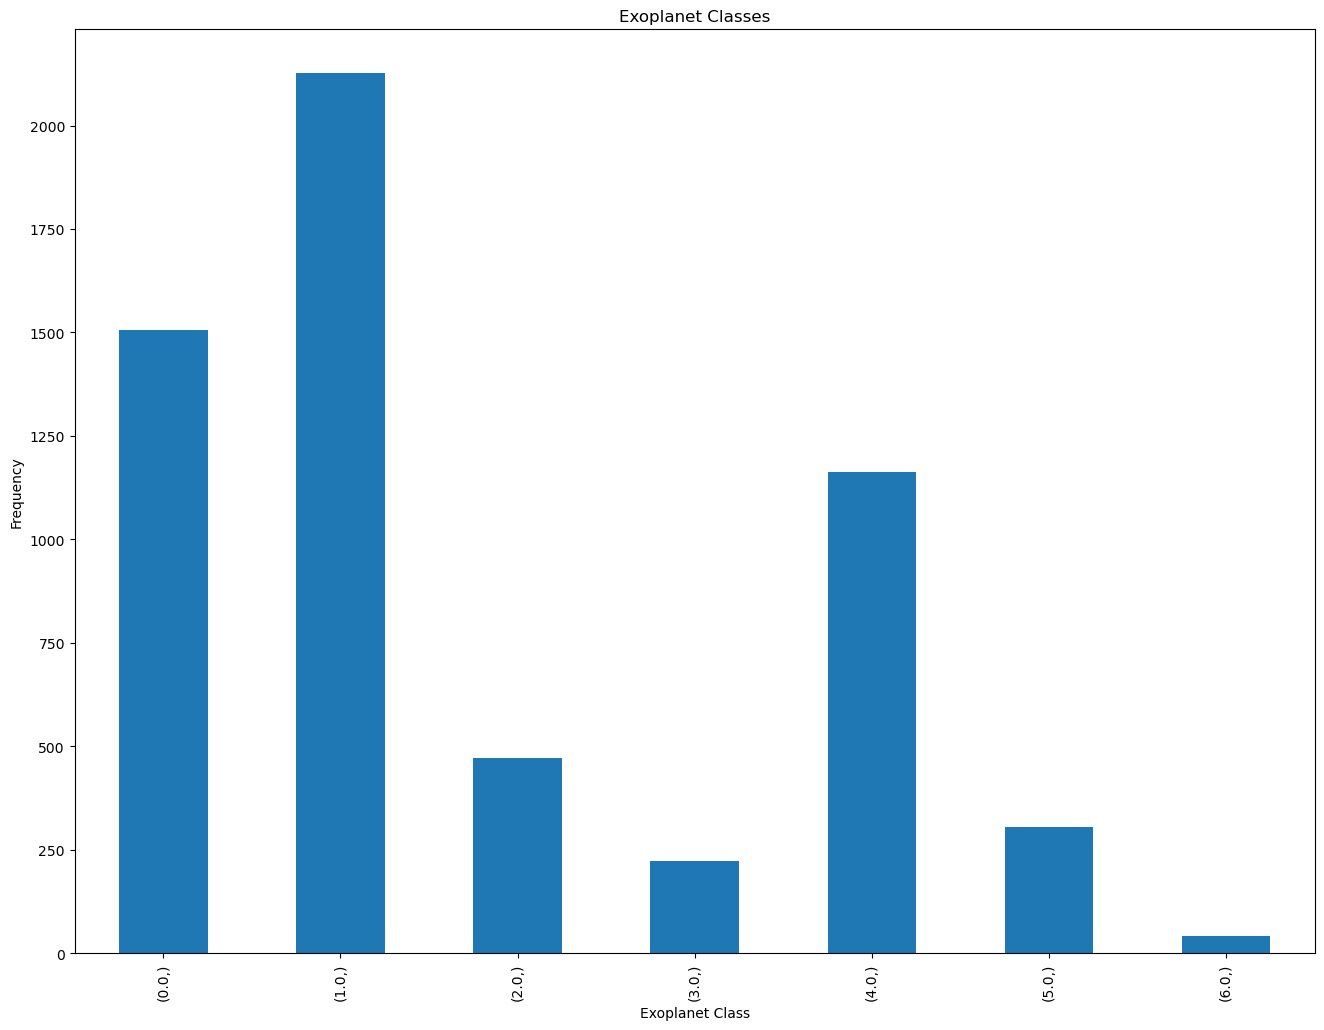

In [7]:
plt.figure(figsize=(16, 12))
y_cleaned.value_counts().sort_index().plot(kind='bar', title='Exoplanet Classes')
plt.xlabel('Exoplanet Class')
plt.ylabel('Frequency')
plt.show()

This data, to me, is pretty interesting. Earth slots somewhere into 0.0 and 1.0. Neptune is somewhere in 4.0. So whats the deal with the the gap? Let's use PCA and Kmeans to see whats up:

In [8]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

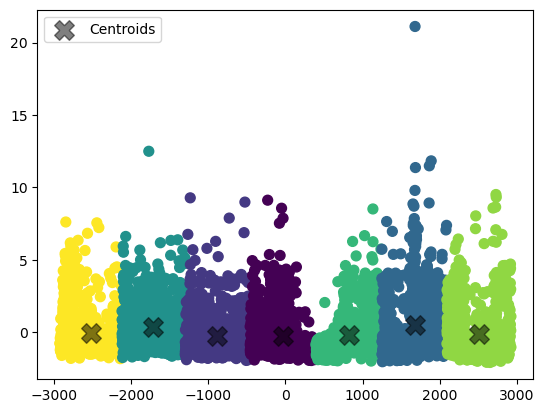

In [9]:
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X_cleaned)

kmeans = KMeans(n_clusters=7, random_state=0, n_init="auto")
kmeans.fit(X_reduced)
y_kmeans = kmeans.predict(X_reduced)

plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=y_kmeans, s=50, cmap='viridis')

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5, marker='X', label='Centroids')
plt.legend()
plt.show()

You can see the dip around ~300 on the X-axis (this is PCA, though, so who knows what that is actually measuring.) Let's compare this against our given y:

In [10]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import silhouette_score

In [11]:
cm = confusion_matrix(y_cleaned, y_kmeans)

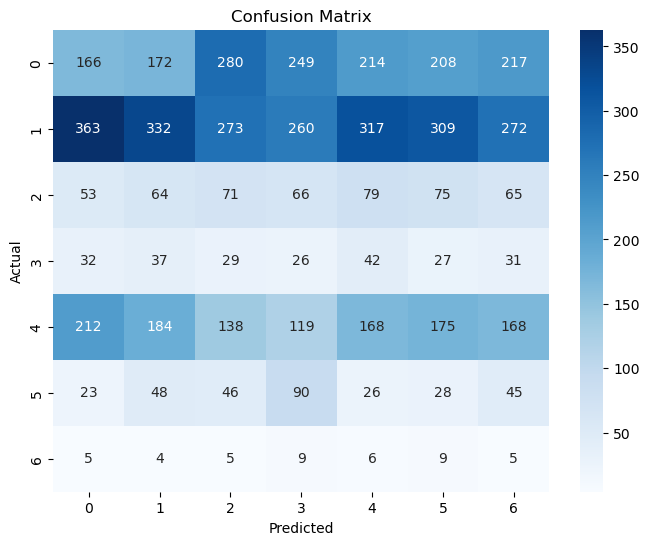

In [12]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Wow this sucks!! 

In [13]:
silhouette_score(X_cleaned, y_kmeans)

0.5472675724418676

This means that there _is_ a structure in the clustering, but it's not super well defined!

Let's try this again without the pca!

In [14]:
kmeans2 = KMeans(n_clusters=7, random_state=0, n_init="auto")
kmeans2.fit(X_cleaned)
y_kmeans2 = kmeans2.predict(X_cleaned)

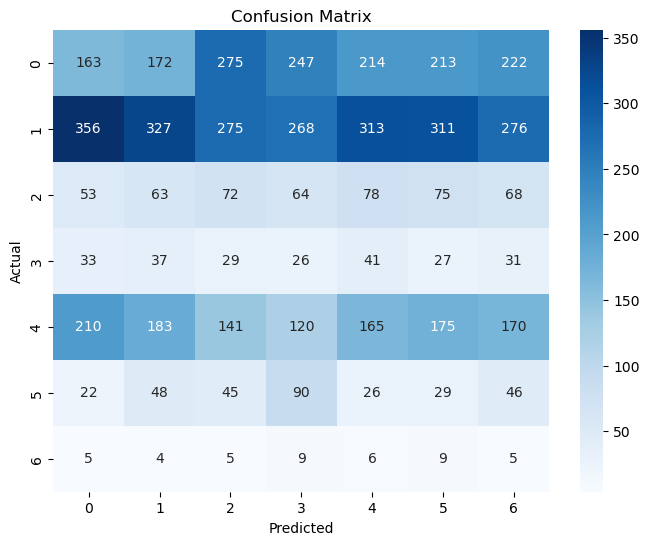

In [15]:
cm = confusion_matrix(y_cleaned, y_kmeans2)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

#### Fixing this with SMOTE


In [21]:
from imblearn.over_sampling import SMOTE

In [22]:
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_cleaned, y_cleaned)

In [23]:
kmeans3 = KMeans(n_clusters=7, random_state=0, n_init="auto")
kmeans3.fit(X_res)
y_kmeans3 = kmeans3.predict(X_res)

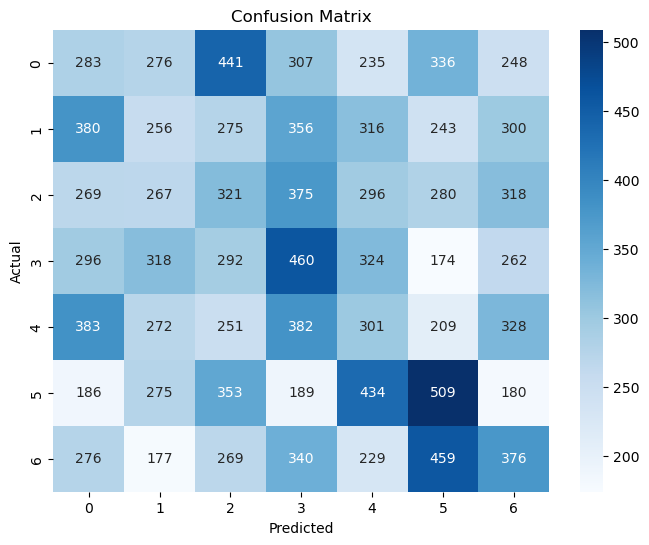

In [24]:
cm = confusion_matrix(y_res, y_kmeans3)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Interesting!

In [28]:
from sklearn.mixture import GaussianMixture

In [33]:
gm = GaussianMixture(n_components=7, random_state=0).fit(X_cleaned)
y_GM = gm.predict(X_cleaned)

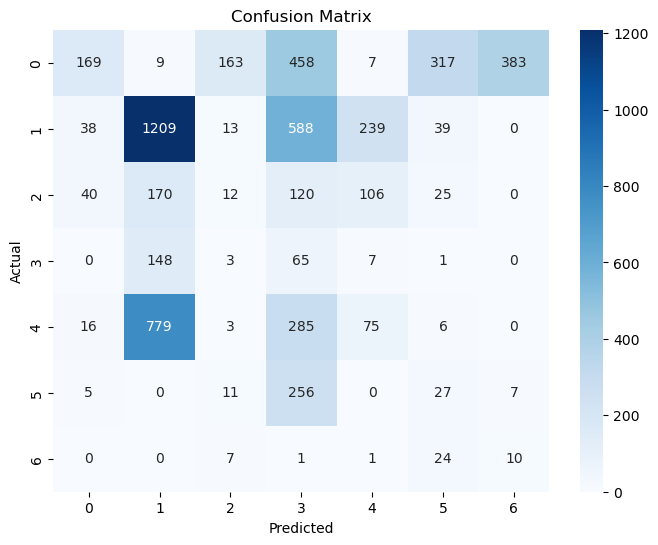

In [35]:
cm = confusion_matrix(y_cleaned, y_GM)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## Lets Classify!



Lets start dead simple, knn. We're going to start with ingoring the SMOTE, just because it wasn't the best results.

In [54]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import top_k_accuracy_score

In [55]:
X_train, X_test, y_train, y_test = train_test_split(X_cleaned, y_cleaned, test_size=0.2, random_state=42)

In [56]:
neigh = KNeighborsClassifier(n_neighbors=3)
neigh.fit(X_train, y_train.values.ravel())
y_pred = neigh.predict(X_test)

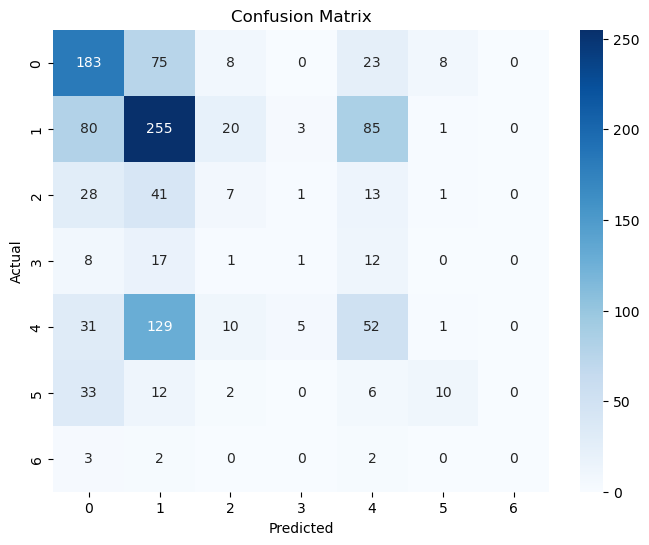

In [57]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [65]:
y_score = neigh.predict_proba(X_test)
top_one = top_k_accuracy_score(y_test, y_score, k=1)
top_three = top_k_accuracy_score(y_test, y_score, k=3)

print(f'Top One Score of: {top_one}')
print(f'Top Three Score of: {top_three}')

Top One Score of: 0.3712574850299401
Top Three Score of: 0.6817792985457656


There is a high degree of class overlap. Because Top-3 is nearly double the Top-1, we can conclude that the features are strong enough to narrow the possibilities down to a "shortlist," but they aren't unique enough to clinch the final decision.

"KNN struggled because exoplanets exist on a physical spectrum. Even after pruning the features to the most important variables, the 'neighborhoods' of different planet types remained intermingled. The 31% gap between my Top-1 and Top-3 accuracy proves the model could find the right 'solar neighborhood,' but couldn't distinguish between the similar 'neighbors' living there."

SOmething something global (Neural Net, DT, etc.) vs local (KNN). "You can argue that KNN failed because it was too "democratic"—it gave a vote to lower-importance features like star_vmag, which likely added more noise than clarity to the distance calculation."

#### Showing this using PCA!

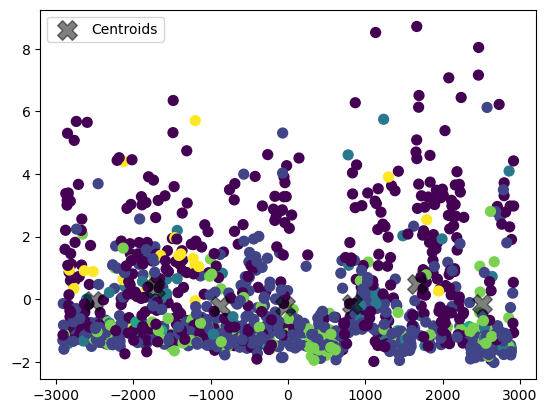

In [66]:
X_train, X_test, y_train, y_test = train_test_split(X_reduced, y_cleaned, test_size=0.2, random_state=42)

neigh = KNeighborsClassifier(n_neighbors=3)
neigh.fit(X_train, y_train.values.ravel())
y_pred = neigh.predict(X_test)

plt.scatter(X_test[:, 0], X_test[:, 1], c=y_pred, s=50, cmap='viridis')

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5, marker='X', label='Centroids')
plt.legend()
plt.show()

what a nightmare!